In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import * 

# Load feature tables 

In [68]:
from pathlib import Path
import pandas as pd
import numpy as np

base = Path("clean_tables")
PRIMARY_KEY = "RowKey"

# 1. Load feature tables
sql_df    = pd.read_csv(base / "sql_metrics.csv")
static_df = pd.read_csv(base / "static_metrics.csv")
dynamic_df= pd.read_csv(base / "dynamic_metrics.csv")
graph_df = pd.read_csv(base / "graph_metrics.csv")
qiskit_df  = pd.read_csv(base / "qiskit_simulation.csv")
rdbms_df  = pd.read_csv(base / "rdbms_simulation.csv")

# 2. Merge feature tables first (numeric features)
feature_df = sql_df # Only use SQL features for RDBMS analysis

# feature_df = sql_df.merge(static_df, on=PRIMARY_KEY, how="outer") \
#                        .merge(dynamic_df, on=PRIMARY_KEY, how="outer") \
#                        .merge(graph_df, on=PRIMARY_KEY, how="outer") \
# 3. FEATURES = numeric columns only (excluding PRIMARY_KEY)

FEATURES = feature_df.select_dtypes(include=[np.number]).columns.tolist()

# 4. Keep only memory_usage / execution_time columns
keep_suffixes = ["mb", "time_s"]
rdbms_cols = [PRIMARY_KEY] + [c for c in rdbms_df.columns if any(c.endswith(s) for s in keep_suffixes)]
rdbms_df = rdbms_df[rdbms_cols]

# 5. Merge feature_df with RDBMS columns to get final ML-ready df
df = feature_df.merge(rdbms_df, on=PRIMARY_KEY)
# Drop columns with nan in FEATURES
# Print initial number of rows
print("Initial rows before filtering automatic simulation:", len(df))
df = df.dropna(subset=FEATURES, how='any')
print("Rows after dropping NaNs in FEATURES:", len(df))

sim_cols = [c for c in rdbms_df.columns if c != PRIMARY_KEY]
df["at_least_one_sim"] = df[sim_cols].notna().any(axis=1)

print("Rows after filtering automatic simulation:", len(df))
print("Number of numeric feature columns:", len(FEATURES))
print("FEATURES sample:", FEATURES)


C:\Users\aadik\AppData\Local\Temp\ipykernel_15500\2313337000.py:13: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  qiskit_df  = pd.read_csv(base / "qiskit_simulation.csv")


Initial rows before filtering automatic simulation: 775
Rows after dropping NaNs in FEATURES: 775
Rows after filtering automatic simulation: 775
Number of numeric feature columns: 11
FEATURES sample: ['num_agg_funcs', 'num_and_clauses', 'num_subqueries_with', 'num_eq_predicates', 'num_group_bys', 'num_join_occurrences', 'num_joins', 'num_unique_join_edges', 'num_order_bys', 'num_select_columns', 'num_where_clauses']


# Generated query (Tim's code) has highly correlated features

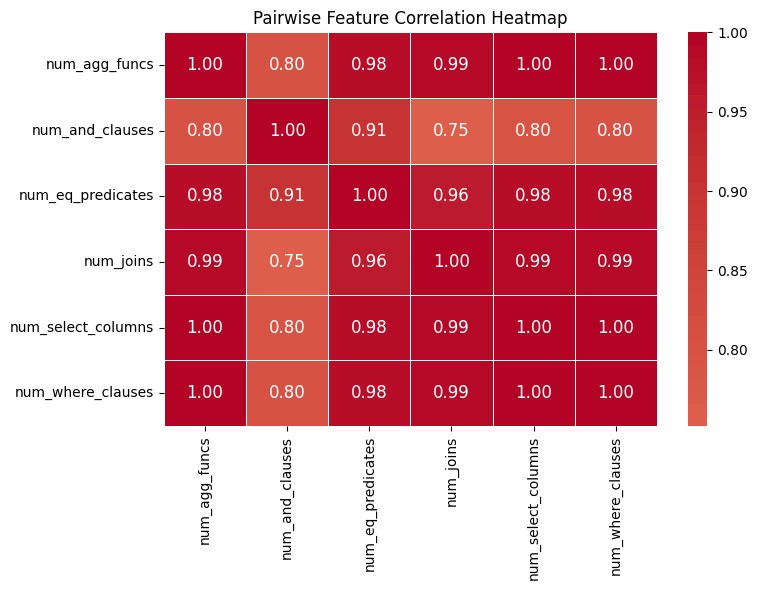

num_and_clauses       103
num_joins             142
num_select_columns    189
num_agg_funcs         190
num_where_clauses     192
num_eq_predicates     249
dtype: int64

In [69]:
# Plot the correlation matrix using utils.PlotCorrelationMatrix
from utils import PlotCorrelationMatrix
DROP_COLS = [
    "num_subqueries_with",
    "num_order_bys",
    "num_group_bys",
    "num_unique_join_edges",
    "num_join_occurrences",
    # "num_select_columns",
    # "num_where_clauses",
] # drop columns with low variance or non-meaningful

FEATURES = [c for c in FEATURES if c not in DROP_COLS]
pcm = PlotCorrelationMatrix(df, FEATURES, (8, 6))
# print nonunique columns
df[FEATURES].nunique().sort_values()


Best execution time counts:
 best_time_method
sqlite    681
Name: count, dtype: int64

Best memory usage counts:
 best_mem_method
sqlite    681
Name: count, dtype: int64


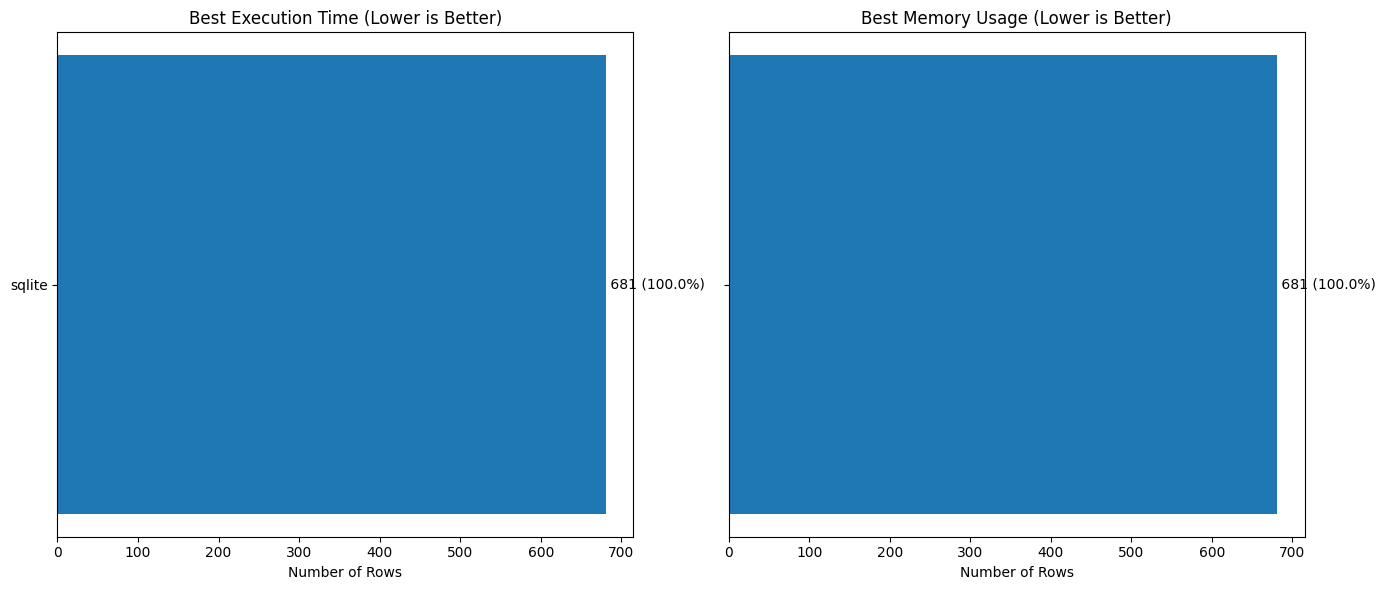

In [70]:
import matplotlib.pyplot as plt

METHODS = ["sqlite"] # "ducksql", "psql", "infiniquantum" really bad. Add methods to see the histograms

# Metric columns
time_cols = {m: [c for c in df.columns if c.endswith("time_s") and m in c] for m in METHODS}
mem_cols  = {m: [c for c in df.columns if c.endswith("mb") and m in c] for m in METHODS}

# Best per row
def best_method(row, col_map):
    vals = {m: row[cols].min() for m, cols in col_map.items() if cols and pd.notna(row[cols].min())}
    return min(vals, key=vals.get) if vals else np.nan

df["best_time_method"] = df.apply(best_method, axis=1, col_map=time_cols)
df["best_mem_method"]  = df.apply(best_method, axis=1, col_map=mem_cols)

# Counts
time_counts = df["best_time_method"].value_counts().reindex(METHODS, fill_value=0)
mem_counts  = df["best_mem_method"].value_counts().reindex(METHODS, fill_value=0)
print("Best execution time counts:\n", time_counts)
print("\nBest memory usage counts:\n", mem_counts)

# Plot 1x2 histograms with percentages
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, counts, title in zip(axes, [time_counts, mem_counts], ["Best Execution Time", "Best Memory Usage"]):
    ax.barh(counts.index, counts.values)
    ax.set_title(f"{title} (Lower is Better)")
    ax.set_xlabel("Number of Rows")
    total = counts.sum()
    for i, c in enumerate(counts.values):
        pct = 100*c/total if total else 0
        ax.text(c, i, f" {c} ({pct:.1f}%)", va="center")
plt.tight_layout()
plt.show()


Best execution time counts:
 best_time_method
sqlite                   71
density_matrix          233
matrix_product_state    439
extended_stabilizer      32
Name: count, dtype: int64

Best memory usage counts:
 best_mem_method
sqlite                  272
density_matrix          110
matrix_product_state    196
extended_stabilizer     197
Name: count, dtype: int64


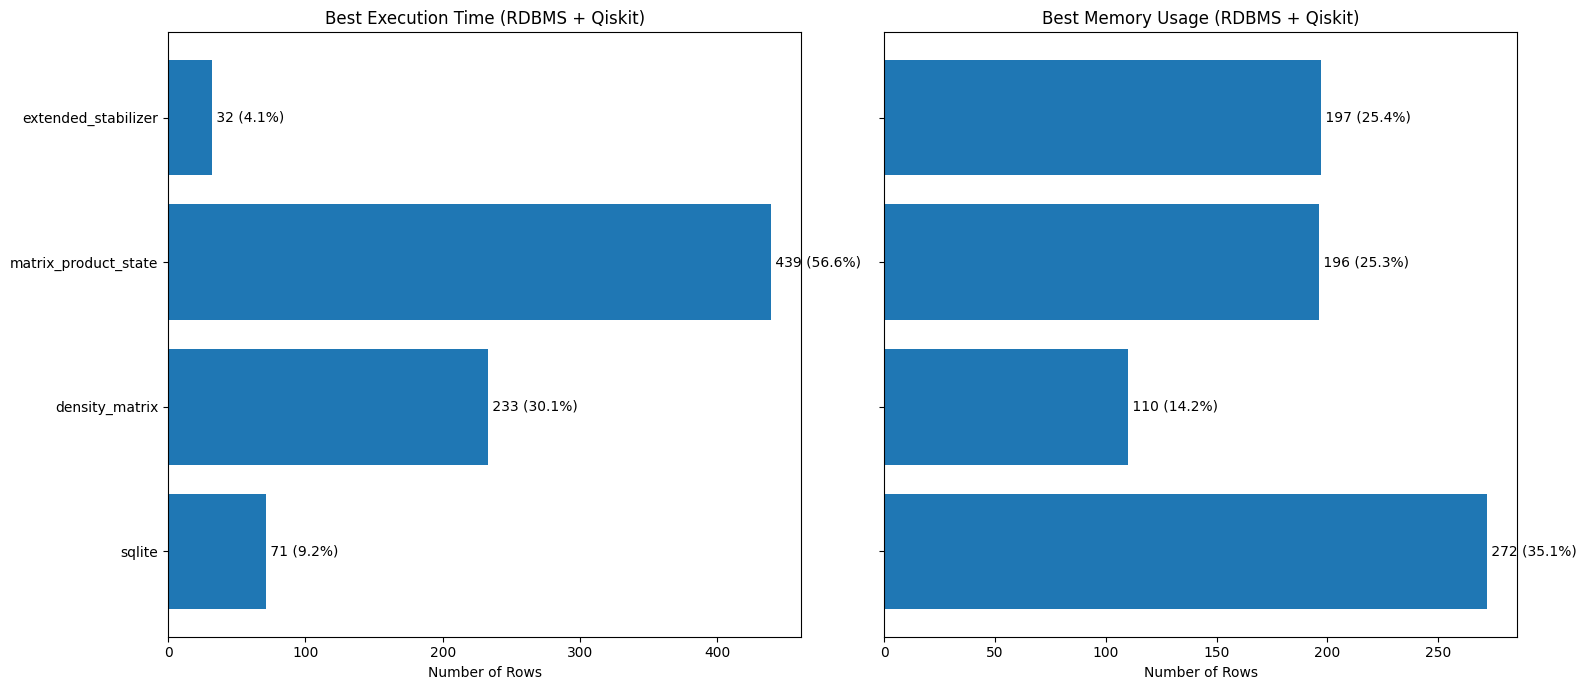

In [71]:
import matplotlib.pyplot as plt

# Merge Qiskit
df_with_qiskit = df.merge(qiskit_df, on=PRIMARY_KEY, suffixes=("", "_qiskit"))

# Method definitions
RDBMS_METHODS = METHODS
QISKIT_METHODS = ["density_matrix", "matrix_product_state", "extended_stabilizer"] # no statevector or statevector_saved
ALL_METHODS = RDBMS_METHODS + QISKIT_METHODS

# Build column maps
time_cols = {m: [c for c in df_with_qiskit.columns if m in c and c.endswith(("time_s","execution_time"))] for m in ALL_METHODS}
mem_cols  = {m: [c for c in df_with_qiskit.columns if m in c and c.endswith(("mb","memory_usage"))] for m in ALL_METHODS}

# Best method per row
def best_method(row, col_map):
    vals = {m: row[cols].min() for m, cols in col_map.items() if cols and pd.notna(row[cols].min())}
    return min(vals, key=vals.get) if vals else np.nan

df_with_qiskit["best_time_method"] = df_with_qiskit.apply(best_method, axis=1, col_map=time_cols)
df_with_qiskit["best_mem_method"]  = df_with_qiskit.apply(best_method, axis=1, col_map=mem_cols)

# Counts
time_counts = df_with_qiskit["best_time_method"].value_counts().reindex(ALL_METHODS, fill_value=0)
mem_counts  = df_with_qiskit["best_mem_method"].value_counts().reindex(ALL_METHODS, fill_value=0)

print("Best execution time counts:\n", time_counts)
print("\nBest memory usage counts:\n", mem_counts)

# Plot horizontal 1x2 histograms with percentages
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, counts, title in zip(axes, [time_counts, mem_counts], ["Best Execution Time", "Best Memory Usage"]):
    ax.barh(counts.index, counts.values)
    ax.set_title(f"{title} (RDBMS + Qiskit)")
    ax.set_xlabel("Number of Rows")
    total = counts.sum()
    for i, c in enumerate(counts.values):
        pct = 100*c/total if total else 0
        ax.text(c, i, f" {c} ({pct:.1f}%)", va="center")
plt.tight_layout()
plt.show()


# Multiclass Qiskit and RDBMS methods

c:\Users\aadik\InferQ\analysis\venv\Lib\site-packages\xgboost\core.py:771: FutureWarning: Pass `objective` as keyword args.
  warnings.warn(msg, FutureWarning)


Random Forest        accuracy = 0.593
Decision Tree        accuracy = 0.567
Logistic Regression  accuracy = 0.572
Linear SVM           accuracy = 0.557
KNN                  accuracy = 0.567
XGBoost              accuracy = 0.603


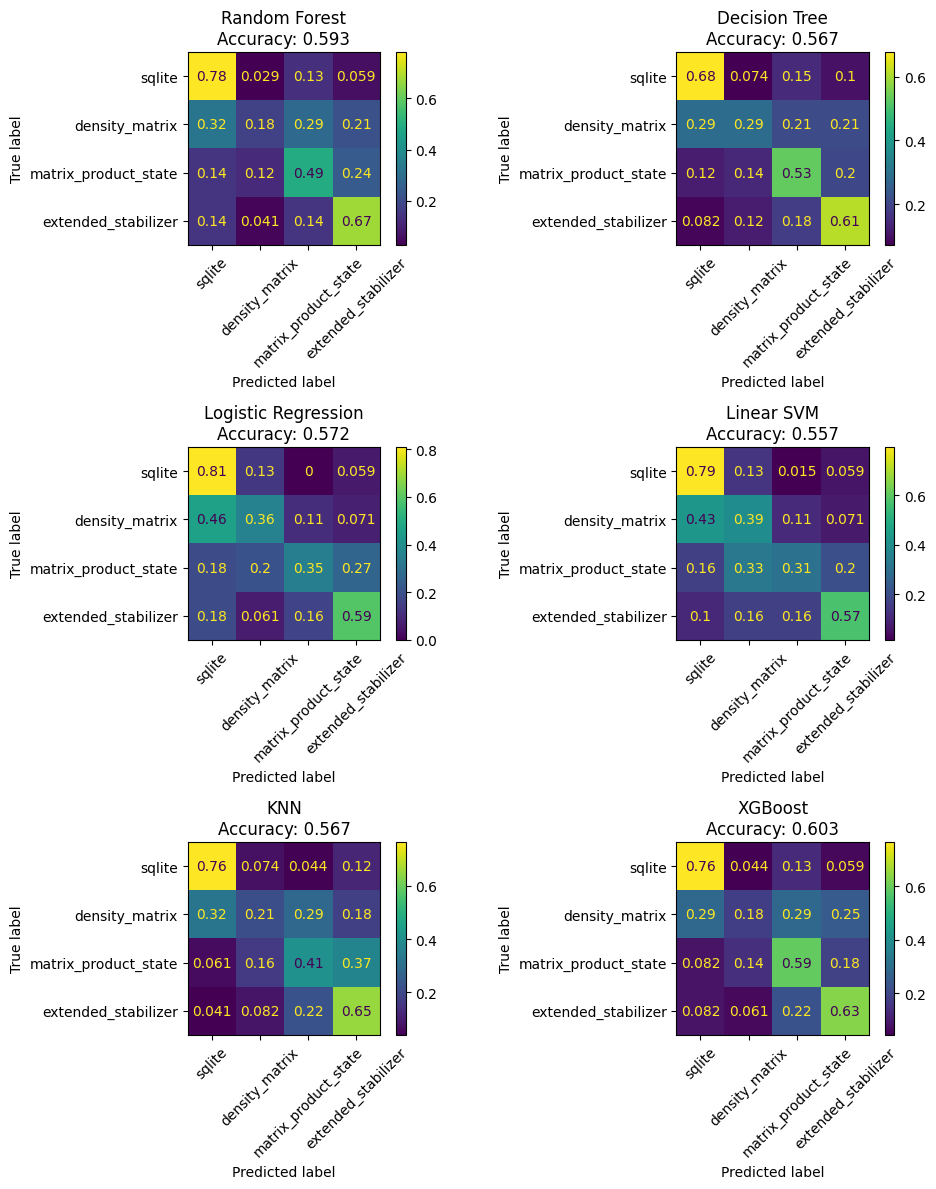

In [72]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from utils import PlotConfusionReports

# --- data ---
X, y = df_with_qiskit[FEATURES], df_with_qiskit["best_mem_method"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# --- label encoding + class weights ---
le = LabelEncoder()
y_train_enc, y_test_enc = le.fit_transform(y_train), le.transform(y_test)
cw_enc = dict(zip(np.unique(y_train_enc), compute_class_weight("balanced", classes=np.unique(y_train_enc), y=y_train_enc)))
sw_xgb = np.array([cw_enc[c] for c in y_train_enc])

# --- models ---
models = {
    "Random Forest": RandomForestClassifier(300, class_weight="balanced", n_jobs=-1, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "Linear SVM": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="linear", class_weight="balanced"))]),
    "KNN": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(7))]),
    "XGBoost": XGBClassifier(300, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
                             objective="multi:softmax", num_class=len(le.classes_), eval_metric="mlogloss", random_state=42)
}

# --- train / predict ---
preds = {}
for name, model in models.items():
    if name == "XGBoost":
        model.fit(X_train, y_train_enc, sample_weight=sw_xgb)
        y_pred = le.inverse_transform(model.predict(X_test))
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    preds[name] = y_pred
    print(f"{name:20s} accuracy = {accuracy_score(y_test, y_pred):.3f}")

# --- confusion plots ---
PlotConfusionReports(y_test, preds, ALL_METHODS)


# RDBMS vs Qiskit BINARY classification

Class distribution:
 family
qiskit    503
rdbms     272
Name: count, dtype: int64 

Random Forest        accuracy = 0.817
              precision    recall  f1-score   support

      qiskit      0.815     0.929     0.868       252
       rdbms      0.822     0.610     0.700       136

    accuracy                          0.817       388
   macro avg      0.819     0.769     0.784       388
weighted avg      0.818     0.817     0.809       388

--------------------------------------------------
Decision Tree        accuracy = 0.747
              precision    recall  f1-score   support

      qiskit      0.803     0.810     0.806       252
       rdbms      0.642     0.632     0.637       136

    accuracy                          0.747       388
   macro avg      0.722     0.721     0.722       388
weighted avg      0.747     0.747     0.747       388

--------------------------------------------------
Logistic Regression  accuracy = 0.781
              precision    recall  f1-score   

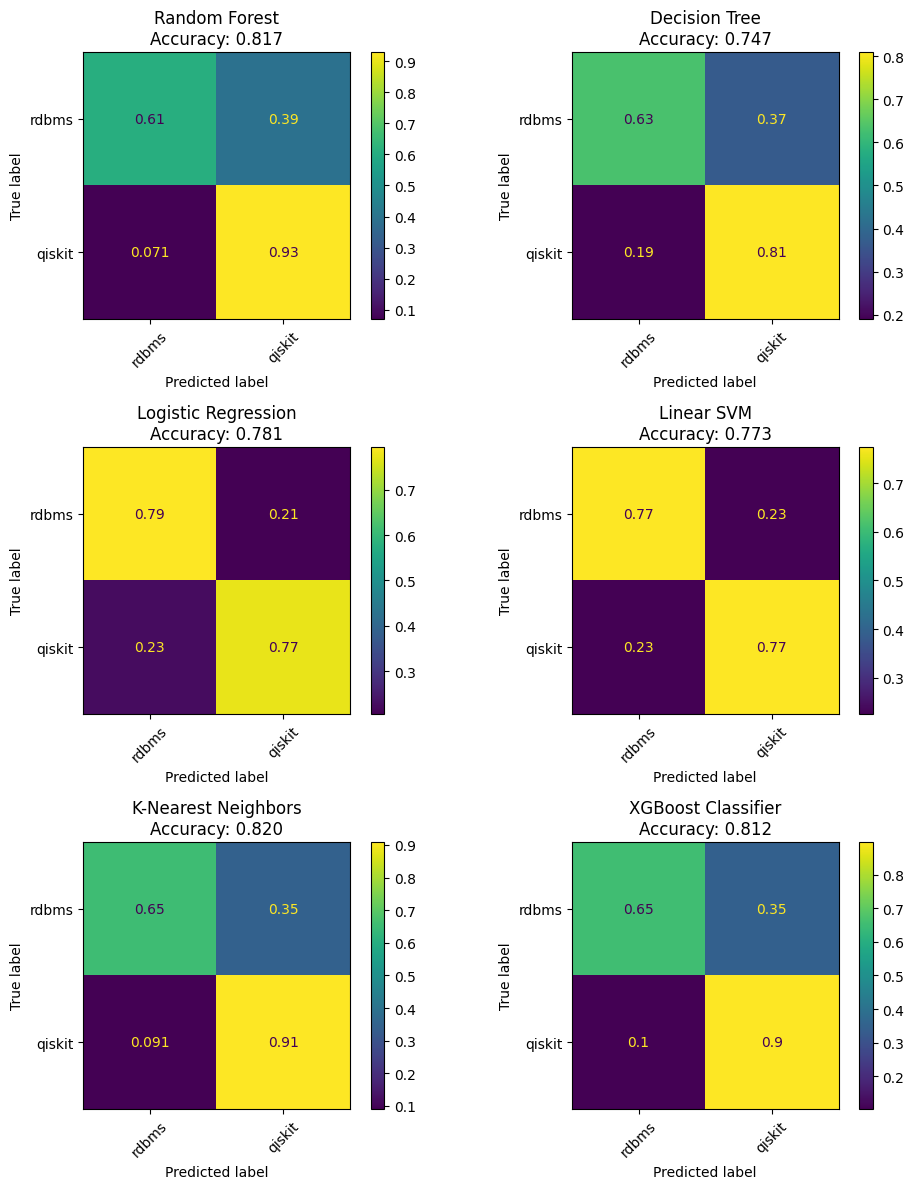

In [73]:
from sklearn.metrics import classification_report

# --- binary target ---
RDBMS_METHODS = {"psql", "ducksql", "sqlite", "infiniquantum"}
QISKIT_METHODS = {"statevector_saved", "density_matrix", "matrix_product_state", "extended_stabilizer"}

df_bin = df_with_qiskit.copy()
df_bin["family"] = df_bin["best_mem_method"].apply(
    lambda m: "rdbms" if m in RDBMS_METHODS else "qiskit" if m in QISKIT_METHODS else np.nan
)
df_bin = df_bin.dropna(subset=["family"])

X, y = df_bin[FEATURES], df_bin["family"]
print("Class distribution:\n", y.value_counts(), "\n")

# --- split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

# --- encoding + weights ---
le = LabelEncoder()
y_train_enc, y_test_enc = le.fit_transform(y_train), le.transform(y_test)

cw = dict(zip(
    np.unique(y_train),
    compute_class_weight(class_weight="balanced",
                         classes=np.unique(y_train),
                         y=y_train)
))

cw_enc = dict(zip(
    np.unique(y_train_enc),
    compute_class_weight(class_weight="balanced",
                         classes=np.unique(y_train_enc),
                         y=y_train_enc)
))

sample_weights_xgb = np.array([cw_enc[c] for c in y_train_enc])

# --- models ---
models = {
    "Random Forest": RandomForestClassifier(300, n_jobs=-1, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]),
    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear", class_weight="balanced"))
    ]),
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(7))
    ]),
    "XGBoost Classifier": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        objective="binary:logistic", eval_metric="logloss",
        random_state=42
    )
}

# --- train / evaluate ---
model_to_y_pred = {}

for name, model in models.items():
    if name == "XGBoost Classifier":
        model.fit(X_train, y_train_enc, sample_weight=sample_weights_xgb)
        y_pred = le.inverse_transform((model.predict(X_test) > 0.5).astype(int))
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    model_to_y_pred[name] = y_pred
    print(f"{name:20s} accuracy = {accuracy_score(y_test, y_pred):.3f}")
    print(classification_report(y_test, y_pred, digits=3))
    print("-" * 50)

# --- confusion matrices ---
PlotConfusionReports(y_test, model_to_y_pred, methods=["rdbms", "qiskit"])


# Analysing importance of SQL features for RDBMS profiling


Top 15 most important features (Linear SVM):

              feature  coefficient  abs_importance
3           num_joins     2.729951        2.729951
0       num_agg_funcs    -2.122441        2.122441
4  num_select_columns    -0.958868        0.958868
5   num_where_clauses    -0.799645        0.799645
2   num_eq_predicates    -0.451170        0.451170
1     num_and_clauses     0.352200        0.352200

Top 15 most important features (Logistic Regression):

              feature  coefficient  abs_importance
3           num_joins     1.799325        1.799325
0       num_agg_funcs    -1.696019        1.696019
4  num_select_columns    -1.008111        1.008111
5   num_where_clauses    -0.669749        0.669749
2   num_eq_predicates    -0.400752        0.400752
1     num_and_clauses     0.226519        0.226519


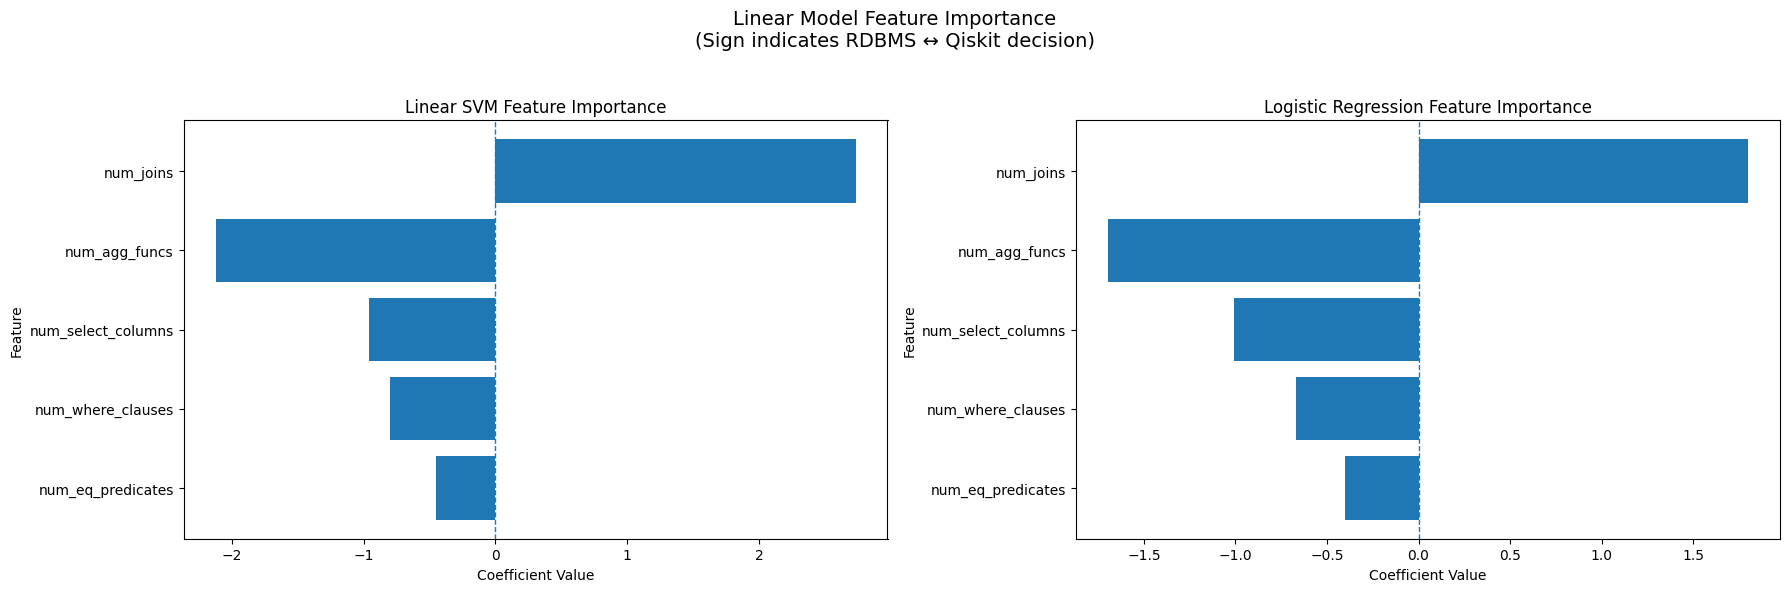


Interpretation:
• Positive coefficient  → pushes prediction toward class 'qiskit'
• Negative coefficient  → pushes prediction toward class 'rdbms'
• Larger magnitude      → stronger influence on decision


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

models_to_compare = {
    "Linear SVM": models["Linear SVM"],
    "Logistic Regression": models["Logistic Regression"]
}

TOP_K = 5
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (name, pipeline) in zip(axes, models_to_compare.items()):

    clf = pipeline.named_steps["clf"]
    coefs = clf.coef_.ravel()

    importance_df = pd.DataFrame({
        "feature": FEATURES,
        "coefficient": coefs,
        "abs_importance": np.abs(coefs)
    }).sort_values("abs_importance", ascending=False)

    print(f"\nTop 15 most important features ({name}):\n")
    print(importance_df.head(15))

    plot_df = importance_df.head(TOP_K).iloc[::-1]

    ax.barh(plot_df["feature"], plot_df["coefficient"])
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title(f"{name} Feature Importance")
    ax.set_xlabel("Coefficient Value")
    ax.set_ylabel("Feature")

fig.suptitle(
    "Linear Model Feature Importance\n(Sign indicates RDBMS ↔ Qiskit decision)",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\nInterpretation:")
print("• Positive coefficient  → pushes prediction toward class 'qiskit'")
print("• Negative coefficient  → pushes prediction toward class 'rdbms'")
print("• Larger magnitude      → stronger influence on decision")


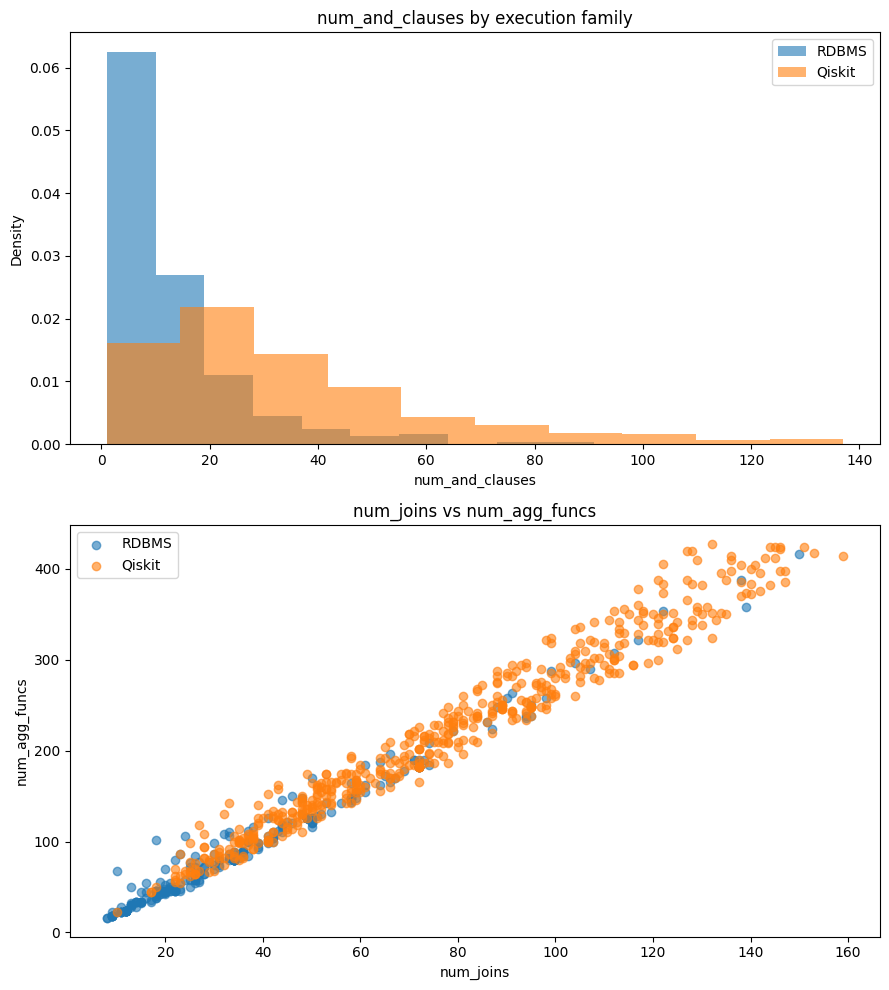

In [75]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(9, 10))

# Histogram: num_and_clauses
axes[0].hist(df_bin.loc[df_bin.family == "rdbms",  "num_and_clauses"],
             bins=10, density=True, alpha=0.6, label="RDBMS")
axes[0].hist(df_bin.loc[df_bin.family == "qiskit", "num_and_clauses"],
             bins=10, density=True, alpha=0.6, label="Qiskit")
axes[0].set_xlabel("num_and_clauses")
axes[0].set_ylabel("Density")
axes[0].set_title("num_and_clauses by execution family")
axes[0].legend()

# Scatter: num_joins vs num_agg_funcs
axes[1].scatter(df_bin.loc[df_bin.family == "rdbms", "num_joins"],
                df_bin.loc[df_bin.family == "rdbms", "num_agg_funcs"],
                alpha=0.6, label="RDBMS")
axes[1].scatter(df_bin.loc[df_bin.family == "qiskit", "num_joins"],
                df_bin.loc[df_bin.family == "qiskit", "num_agg_funcs"],
                alpha=0.6, label="Qiskit")
axes[1].set_xlabel("num_joins")
axes[1].set_ylabel("num_agg_funcs")
axes[1].set_title("num_joins vs num_agg_funcs")
axes[1].legend()

plt.tight_layout()
plt.show()
